# E-Corner Model Test & Debug
ECorner 통합 모델 테스트 및 디버깅 노트북

## 목적
- Steering/Brake/Drive/Suspension/Tire를 묶은 ECorner 단일 코너 모델 검증
- 입력: T_steer, T_brk, T_Drv, T_susp, V_wheel_x, V_wheel_y, X_body (차체 상태 벡터)
  - X_body = [heave, roll, pitch, heave_dot, roll_rate, pitch_rate]
- 출력: F_s (서스펜션 힘), F_x_tire, F_y_tire, 내부 상태(steering_angle, omega_wheel) 추적
- corner_id 별 파라미터(좌/우 조향, roll/pitch 부호) 확인

### 도심 도로 입력/파라미터 가정 (문헌 범위)
- 차속 40~50 km/h, 슬립비 5~10%, 슬립각 2~4 deg (Gillespie, Rajamani 등 일반 승용차 데이터)
- 휠 구동/제동 토크: 0.1g 가속 시 약 120~160 N*m/휠, 0.4~0.6g 제동 시 450~800 N*m/휠 (R~0.3 m 기준)
- EPS 스티어링 랙 토크: 도심 조향 2~4 N*m, 최대는 8~10 N*m (Marouf 2012 EPAS, 일반 승용차 측정 범위)
- 차체 거동: 롤/피치 1~2 deg 내, 도로 입력 heave ±5~10 mm

### 적용 시나리오 요약
- 단일 스텝: 50 km/h, EPS 3 N*m, 구동 130 N*m, 슬립각 약 3 deg 수준의 횡속 입력
- 4코너 비교: 45 km/h, 제동 650 N*m, 롤 1.2 deg / 피치 -0.3 deg
- 복합 시뮬레이션: 50 km/h 베이스, 구동 150→80 N*m, 4.2 s 이후 제동 700 N*m, 스티어링 ±2.8 N*m 사인

In [4]:
# 필요한 라이브러리 import
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 프로젝트 루트를 Python path에 추가
project_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(project_root))

# ECorner import
from vehicle_sim.models.e_corner.e_corner import ECorner, ECornerParameters

print("Import 성공!")
print(f"Project root: {project_root}")

Import 성공!
Project root: c:\Users\hoone\OneDrive\Desktop\SeohanModel\E-Corner_Dynamic_Model


## 1. ECorner 생성 및 기본 상태 확인
- 4개 코너 인스턴스 생성
- corner_id 에 따라 steering/suspension 파라미터가 달라지는지 간단히 확인

In [5]:
corner_ids = ['FL', 'FR', 'RL', 'RR']
corners = {cid: ECorner(corner_id=cid) for cid in corner_ids}

print("=== Corner별 기본 상태 ===")
for cid, model in corners.items():
    st = model.get_state()
    print(f"{cid}: F_s={st['F_s']:.2f} N, F_x={st['F_x_tire']:.2f} N, F_y={st['F_y_tire']:.2f} N, steering_angle={st['steering_angle']:.4f} rad")

print("=== Steering 설정 (좌/우 최대 각) ===")
for cid, model in corners.items():
    print(f"{cid}: +{model.steering.params.max_angle_pos} rad / {model.steering.params.max_angle_neg} rad")

print("=== Suspension corner signs (roll/pitch) ===")
for cid, model in corners.items():
    params = model.suspension.params
    print(f"{cid}: sign_roll={params.sign_roll:+d}, sign_pitch={params.sign_pitch:+d}")

=== Corner별 기본 상태 ===
FL: F_s=0.00 N, F_x=0.00 N, F_y=0.00 N, steering_angle=0.0000 rad
FR: F_s=0.00 N, F_x=0.00 N, F_y=0.00 N, steering_angle=0.0000 rad
RL: F_s=0.00 N, F_x=0.00 N, F_y=0.00 N, steering_angle=0.0000 rad
RR: F_s=0.00 N, F_x=0.00 N, F_y=0.00 N, steering_angle=0.0000 rad
=== Steering 설정 (좌/우 최대 각) ===
FL: +1.570796 rad / -1.570796 rad
FR: +1.570796 rad / -1.570796 rad
RL: +1.570796 rad / -1.570796 rad
RR: +1.570796 rad / -1.570796 rad
=== Suspension corner signs (roll/pitch) ===
FL: sign_roll=+1, sign_pitch=+1
FR: sign_roll=-1, sign_pitch=+1
RL: sign_roll=+1, sign_pitch=-1
RR: sign_roll=-1, sign_pitch=-1


## 2. 단일 스텝 업데이트 (도심 50 km/h)
- 승용차 도심 주행 가정: 차속 50 km/h, EPS 토크 3 N*m, 구동 130 N*m (≈0.1g 수준)
- 슬립각 ~3 deg에 해당하는 횡속 0.65 m/s 입력, 롤/피치 ±1~1.5 deg 내로 제한


In [6]:
corner = corners['FL']
corner.reset()

dt = 0.001

# X_body 배열 생성 [heave, roll, pitch, heave_dot, roll_rate, pitch_rate]
X_body = np.array([
    -0.004,                    # heave [m]
    np.deg2rad(1.3),          # roll [rad]
    np.deg2rad(0.25),         # pitch [rad]
    0.004,                     # heave_dot [m/s]
    np.deg2rad(5.5),          # roll_rate [rad/s]
    np.deg2rad(1.2),          # pitch_rate [rad/s]
])

inputs = dict(
    T_steer=3.0,
    T_brk=0.0,
    T_Drv=130.0,
    T_susp=0.0,
    V_wheel_x=13.9,
    V_wheel_y=0.65,
    X_body=X_body,
)

# 차속에 맞춘 초기 휠 속도 설정 (도심 steady-state 가정)
corner.drive.state.wheel_speed = inputs["V_wheel_x"] / corner.drive.params.R_wheel

F_s, F_x, F_y = corner.update(dt=dt, direction=1, **inputs)

print("=== 단일 업데이트 결과 ===")
print(f"F_s = {F_s:.2f} N, F_x = {F_x:.2f} N, F_y = {F_y:.2f} N")
print(f"steering_angle = {corner.state.steering_angle:.4f} rad, omega_wheel = {corner.state.omega_wheel:.3f} rad/s")
print(f"F_z = {corner.state.F_z:.2f} N (tire vertical force)")

=== 단일 업데이트 결과 ===
F_s = 4795.95 N, F_x = 1348.60 N, F_y = -4792.21 N
steering_angle = 0.0051 rad, omega_wheel = 43.564 rad/s
F_z = 6142.02 N (tire vertical force)


## 3. 4개 코너 비교 (45 km/h 제동)
- 약 0.45~0.5 g 제동 토크 650 N*m, 차속 45 km/h 가정
- 롤 1.2 deg, 피치 -0.3 deg, 횡속 0.55 m/s로 좌/우 부호 및 응답 확인


In [7]:
# 공통 입력 설정
dt = 0.001

# X_body 배열 생성 [heave, roll, pitch, heave_dot, roll_rate, pitch_rate]
X_body = np.array([
    -0.007,                    # heave [m]
    np.deg2rad(1.2),          # roll [rad]
    np.deg2rad(-0.3),         # pitch [rad]
    -0.004,                    # heave_dot [m/s]
    np.deg2rad(6.0),          # roll_rate [rad/s]
    np.deg2rad(2.0),          # pitch_rate [rad/s]
])

test_inputs = dict(
    T_steer=2.5,
    T_brk=650.0,
    T_Drv=0.0,
    T_susp=0.0,
    V_wheel_x=12.5,
    V_wheel_y=0.55,
    X_body=X_body,
)

results = {}
for cid, model in corners.items():
    model.reset()
    model.drive.state.wheel_speed = test_inputs["V_wheel_x"] / model.drive.params.R_wheel
    F_s, F_x, F_y = model.update(dt=dt, **test_inputs)
    results[cid] = {
        "F_s": F_s,
        "F_x": F_x,
        "F_y": F_y,
        "F_z": model.state.F_z,
        "steering_angle": model.state.steering_angle,
    }

print("=== 동일 입력 시 코너별 힘/조향 응답 ===")
for cid in corner_ids:
    r = results[cid]
    print(f"{cid}: F_s={r['F_s']:+8.2f} N, F_z={r['F_z']:+8.2f} N, F_x={r['F_x']:+8.2f} N, F_y={r['F_y']:+8.2f} N, steering_angle={r['steering_angle']:+.4f} rad")

=== 동일 입력 시 코너별 힘/조향 응답 ===
FL: F_s=+4523.80 N, F_z=+6142.02 N, F_x=-1947.03 N, F_y=-4572.10 N, steering_angle=+0.0042 rad
FR: F_s=+6463.80 N, F_z=+6142.02 N, F_x=-1947.03 N, F_y=-4572.10 N, steering_angle=+0.0042 rad
RL: F_s=+2935.30 N, F_z=+3986.96 N, F_x=-1947.03 N, F_y=-3986.96 N, steering_angle=+0.0042 rad
RR: F_s=+4551.94 N, F_z=+3986.96 N, F_x=-1947.03 N, F_y=-3986.96 N, steering_angle=+0.0042 rad


## 4. 시뮬레이션: 도심 혼합 입력 (50 km/h 베이스)
- 50 km/h 기준, 150→80 N*m 구동, 4.2 s 이후 700 N*m 제동, 스티어링 ±2.8 N*m 사인 입력
- Heave ±6 mm, roll ±1 deg, pitch ±0.5 deg 범위에서 연속 업데이트

In [8]:
# 시뮬레이션 설정
dt = 0.001
t_end = 6.0
n_steps = int(t_end / dt)
time = np.arange(n_steps) * dt

corner = ECorner(corner_id="FL")
corner.reset()

base_speed = 13.9  # ~50 km/h 도심 주행 기준
corner.drive.state.wheel_speed = base_speed / corner.drive.params.R_wheel

traces = {
    "time": time,
    "F_s": np.zeros(n_steps),
    "F_x": np.zeros(n_steps),
    "F_y": np.zeros(n_steps),
    "F_z": np.zeros(n_steps),
    "steering_angle": np.zeros(n_steps),
    "omega": np.zeros(n_steps),
    "heave": np.zeros(n_steps),
    "roll": np.zeros(n_steps),
    "pitch": np.zeros(n_steps),
    "T_steer": np.zeros(n_steps),
    "T_brk": np.zeros(n_steps),
    "T_drv": np.zeros(n_steps),
    "T_susp": np.zeros(n_steps),
    # 디버그용 추가 변수
    "delta_s": np.zeros(n_steps),
    "delta_t": np.zeros(n_steps),
    "z_u_abs": np.zeros(n_steps),
    "z_u_dot": np.zeros(n_steps),
}

# 파라미터 진단 출력
print("=== Suspension Parameters ===")
print(f"K_spring = {corner.suspension.params.K_spring:.1f} N/m")
print(f"C_damper_compression = {corner.suspension.params.C_damper_compression:.1f} N*s/m")
print(f"C_damper_rebound = {corner.suspension.params.C_damper_rebound:.1f} N*s/m")
print(f"m_u = {corner.suspension.unsprung_params.m_u:.1f} kg")
print(f"delta_s_min = {corner.suspension.params.delta_s_min:.4f} m (compression limit)")
print(f"delta_s_max = {corner.suspension.params.delta_s_max:.4f} m (extension limit)")
print(f"L_s0 = {corner.suspension.params.L_s0:.4f} m (natural length)")
print(f"z_CG0 = {corner.suspension.params.z_CG0:.4f} m (equilibrium CG height)")

print("\n=== Tire Parameters ===")
print(f"K_t = {corner.suspension.tire_params.K_t:.1f} N/m")
print(f"C_t = {corner.suspension.tire_params.C_t:.1f} N*s/m")
print(f"R_w = {corner.suspension.params.R_w:.4f} m")

print("\n=== Stability Check ===")
omega_sus = np.sqrt(corner.suspension.params.K_spring / corner.suspension.unsprung_params.m_u)
C_damper_avg = (corner.suspension.params.C_damper_compression + corner.suspension.params.C_damper_rebound) / 2
zeta_sus = C_damper_avg / (2 * np.sqrt(corner.suspension.params.K_spring * corner.suspension.unsprung_params.m_u))
print(f"Suspension natural freq = {omega_sus:.2f} rad/s ({omega_sus/(2*np.pi):.2f} Hz)")
print(f"Suspension damping ratio = {zeta_sus:.3f} (avg of compression/rebound)")
print(f"Recommended dt < {2/omega_sus:.4f} s (currently dt={dt}s)")

omega_tire = np.sqrt(corner.suspension.tire_params.K_t / corner.suspension.unsprung_params.m_u)
zeta_tire = corner.suspension.tire_params.C_t / (2 * np.sqrt(corner.suspension.tire_params.K_t * corner.suspension.unsprung_params.m_u))
print(f"Tire natural freq = {omega_tire:.2f} rad/s ({omega_tire/(2*np.pi):.2f} Hz)")
print(f"Tire damping ratio = {zeta_tire:.3f}")
print(f"Recommended dt < {2/omega_tire:.4f} s")

print("\n=== Starting simulation... ===")
for k, t in enumerate(time):
    T_steer = 40 #2.8 * np.sin(0.6 * t)
    T_drv = 500.0 if t < 3.0 else 100.0
    T_brk = 0.0 if t < 4.2 else 0.5
    T_susp = 0

    # Roll, Pitch, Heave를 모두 0으로 설정
    heave = 0.0
    roll = 0.0
    pitch = 0.0
    heave_dot = 0.0
    roll_dot = 0.0
    pitch_dot = 0.0
    
    # X_body 배열 생성
    X_body = np.array([heave, roll, pitch, heave_dot, roll_dot, pitch_dot])

    V_wheel_x = base_speed + 2.0 * np.sin(0.25 * t) - 3.2 * (t >= 4.2) * (t - 4.2)
    V_wheel_y = 0.0 * np.sin(0.55 * t)

    F_s, F_x, F_y = corner.update(
        dt=dt,
        T_steer=T_steer,
        T_brk=T_brk,
        T_Drv=T_drv,
        T_susp=T_susp,
        V_wheel_x=V_wheel_x,
        V_wheel_y=V_wheel_y,
        X_body=X_body,
    )

    traces["F_s"][k] = F_s
    traces["F_x"][k] = F_x
    traces["F_y"][k] = F_y
    traces["F_z"][k] = corner.state.F_z
    traces["steering_angle"][k] = corner.state.steering_angle
    traces["omega"][k] = corner.state.omega_wheel
    traces["heave"][k] = heave
    traces["roll"][k] = roll
    traces["pitch"][k] = pitch
    traces["T_steer"][k] = T_steer
    traces["T_brk"][k] = T_brk
    traces["T_drv"][k] = T_drv
    traces["T_susp"][k] = T_susp
    
    # 디버그 변수 저장
    sus_state = corner.suspension.get_state()
    traces["delta_s"][k] = sus_state["delta_s"]
    traces["delta_t"][k] = sus_state["delta_t"]
    traces["z_u_abs"][k] = sus_state["z_u_abs"]
    traces["z_u_dot"][k] = sus_state["z_u_dot"]
    
    # 초반 5 스텝 디버그 출력
    if k < 5:
        print(f"\n[Step {k}, t={t:.3f}s]")
        print(f"  Input: heave={heave*1000:.2f}mm, roll={np.rad2deg(roll):.2f}deg, pitch={np.rad2deg(pitch):.2f}deg")
        print(f"  Suspension: delta_s={sus_state['delta_s']*1000:.2f}mm, F_s={F_s:.1f}N")
        print(f"  Tire: delta_t={sus_state['delta_t']*1000:.2f}mm, F_z={corner.state.F_z:.1f}N")
        print(f"  Unsprung: z_u_abs={sus_state['z_u_abs']:.4f}m, z_u_dot={sus_state['z_u_dot']:.4f}m/s")
        print(f"  Wheel: omega={corner.state.omega_wheel:.2f}rad/s")

print("\n시뮬레이션 완료!")
print(f"Final values:")
print(f"  omega_wheel: {traces['omega'][-1]:.2f} rad/s")
print(f"  delta_s: {traces['delta_s'][-1]*1000:.2f} mm")
print(f"  delta_t: {traces['delta_t'][-1]*1000:.2f} mm")
print(f"  F_z: {traces['F_z'][-1]:.1f} N")
print(f"  Max |omega|: {np.max(np.abs(traces['omega'])):.2f} rad/s")
print(f"  Max |delta_s|: {np.max(np.abs(traces['delta_s']))*1000:.2f} mm")
print(f"  Max |delta_t|: {np.max(np.abs(traces['delta_t']))*1000:.2f} mm")

=== Suspension Parameters ===
K_spring = 48000.0 N/m
C_damper_compression = 1400.2 N*s/m
C_damper_rebound = 2800.2 N*s/m
m_u = 74.1 kg
delta_s_min = -5.2000 m (compression limit)
delta_s_max = 5.2000 m (extension limit)
L_s0 = 0.4634 m (natural length)
z_CG0 = 0.6540 m (equilibrium CG height)

=== Tire Parameters ===
K_t = 349500.0 N/m
C_t = 708.6 N*s/m
R_w = 0.3210 m

=== Stability Check ===
Suspension natural freq = 25.45 rad/s (4.05 Hz)
Suspension damping ratio = 0.557 (avg of compression/rebound)
Recommended dt < 0.0786 s (currently dt=0.001s)
Tire natural freq = 68.67 rad/s (10.93 Hz)
Tire damping ratio = 0.070
Recommended dt < 0.0291 s

=== Starting simulation... ===

[Step 0, t=0.000s]
  Input: heave=0.00mm, roll=0.00deg, pitch=0.00deg
  Suspension: delta_s=-112.81mm, F_s=5414.9N
  Tire: delta_t=17.57mm, F_z=6142.0N
  Unsprung: z_u_abs=0.3034m, z_u_dot=-0.0000m/s
  Wheel: omega=44.30rad/s

[Step 1, t=0.001s]
  Input: heave=0.00mm, roll=0.00deg, pitch=0.00deg
  Suspension: delta_

## 5. 시뮬레이션 결과 시각화
- Forces/Steering/Wheel speed, 차체 상태, 액추에이터 입력을 플롯

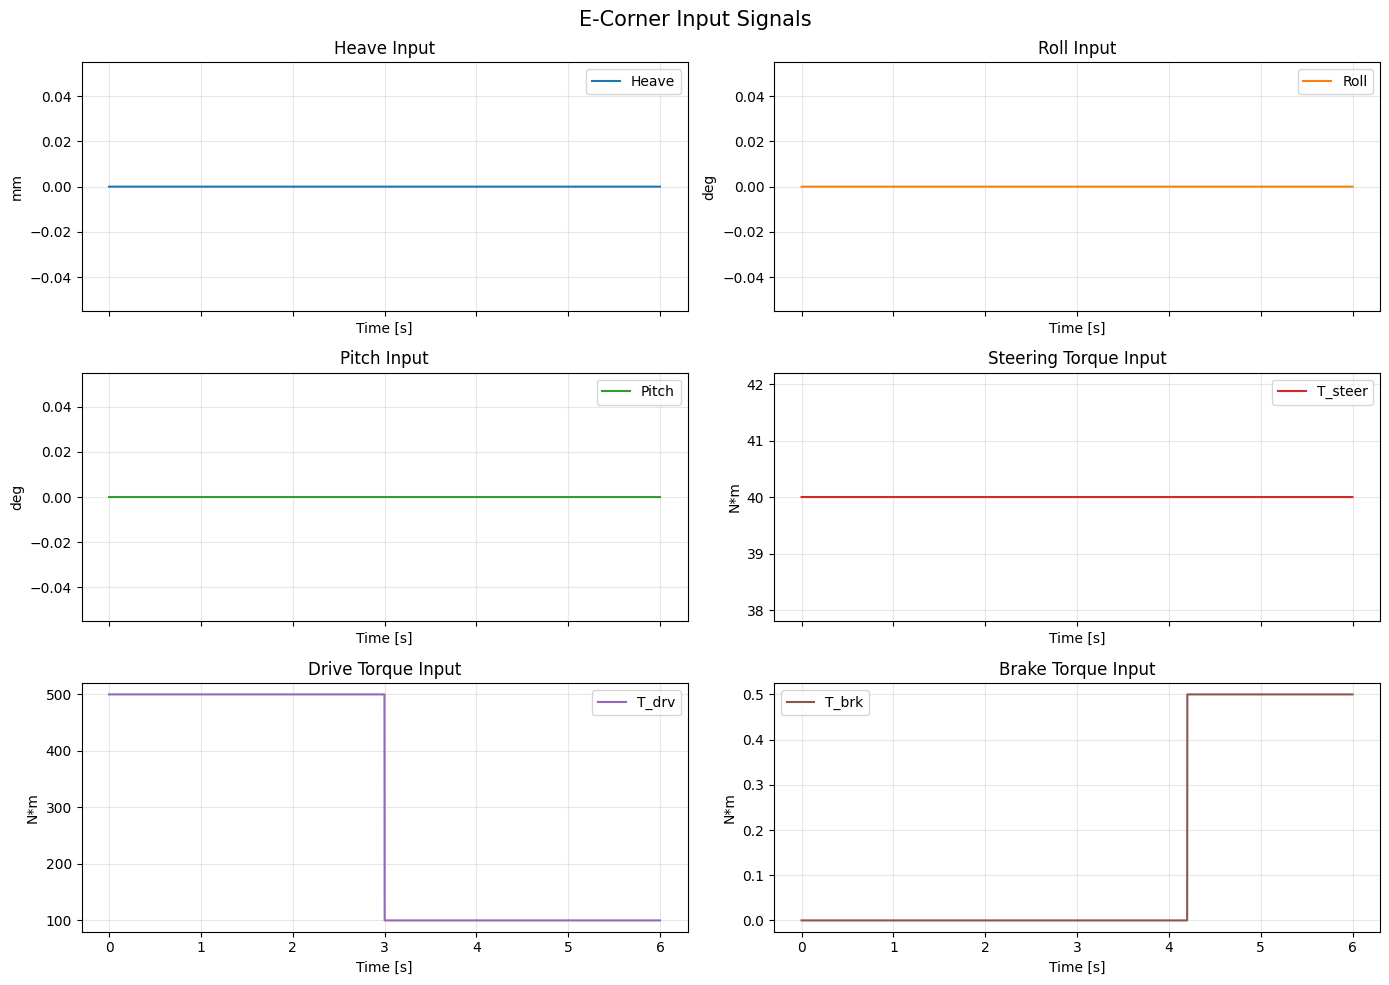

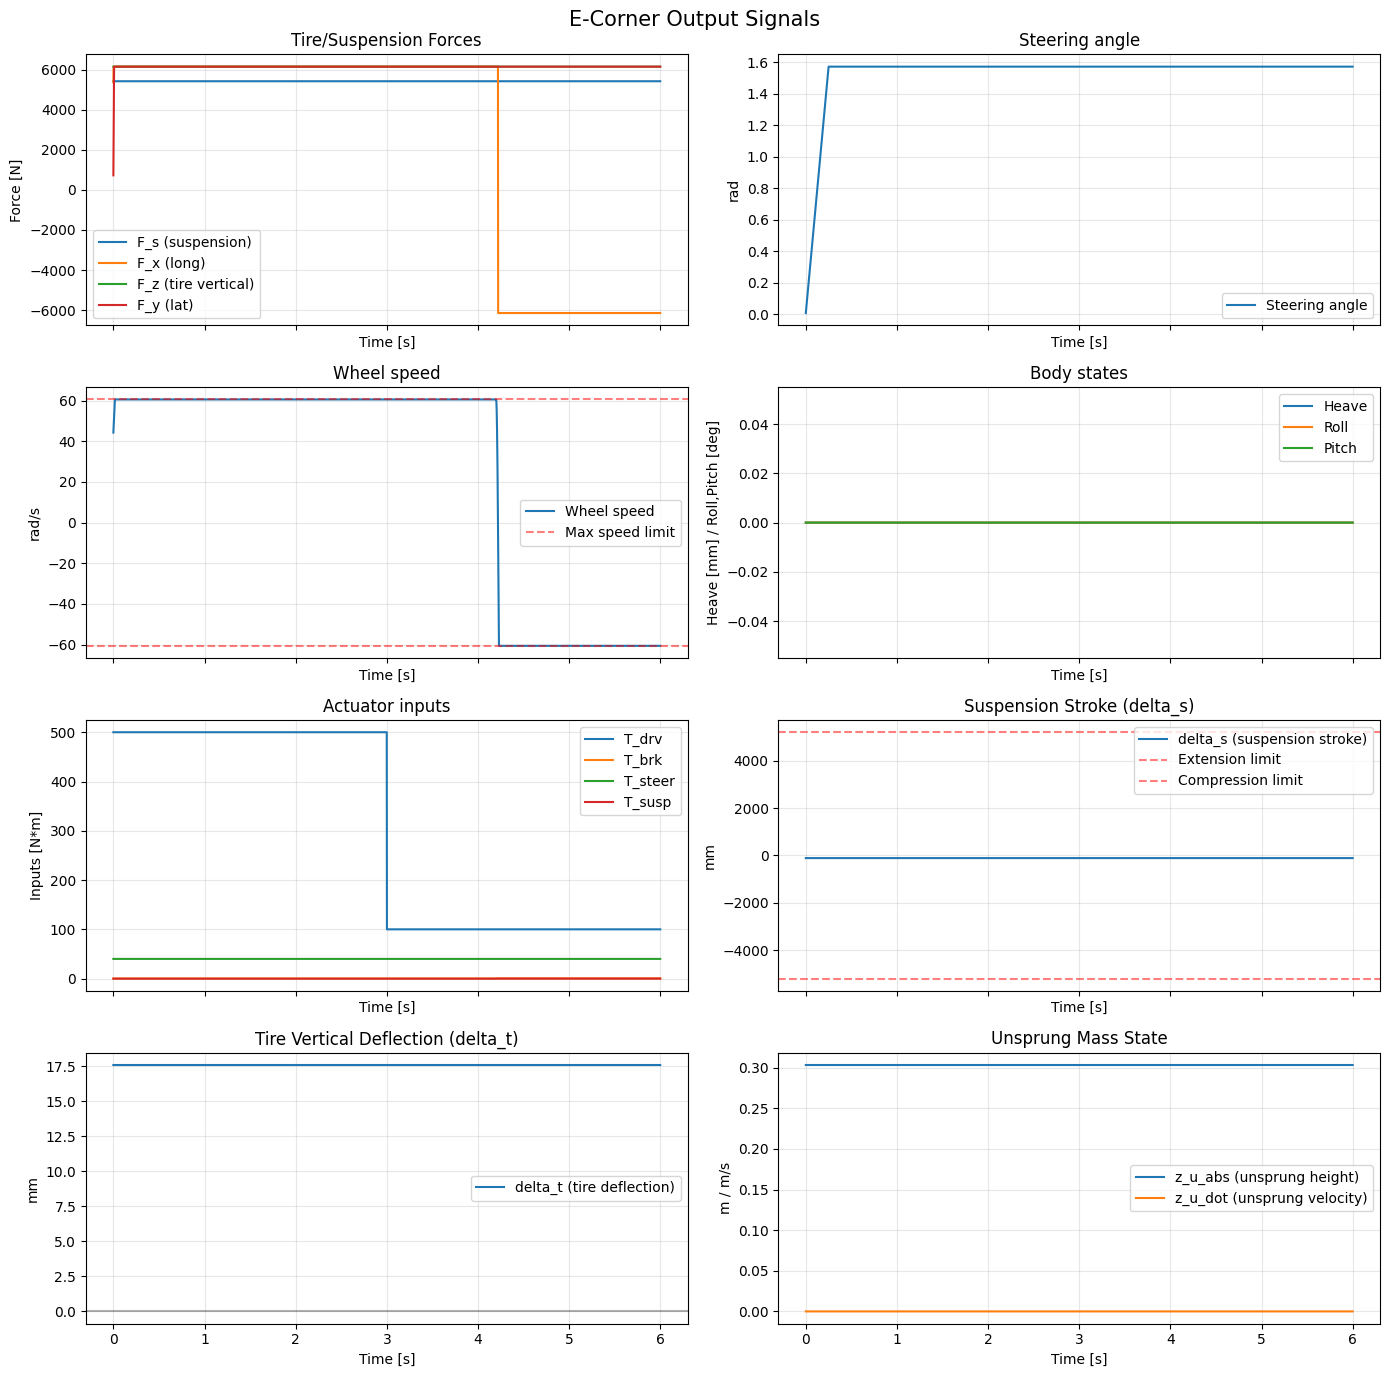


=== Simulation Statistics ===
Wheel speed range: [-60.63, 60.63] rad/s
delta_s range: [-112.81, -112.81] mm (limits: [-5200.0, 5200.0])
F_z range: [6142.0, 6142.0] N
F_s range: [5414.9, 5414.9] N

=== Limit Violations ===
Suspension stroke violations: 0/6000 steps (0.0%)
Tire deflection violations: 0/6000 steps (0.0%)
Wheel speed violations: 0/6000 steps (0.0%)


In [9]:
# 입력 시각화
fig_input, axes_input = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
axes_input = axes_input.ravel()
t = traces["time"]

axes_input[0].plot(t, traces["heave"]*1000, label="Heave", color='C0')
axes_input[0].set_ylabel("mm")
axes_input[0].set_title("Heave Input")
axes_input[0].grid(True, alpha=0.3)
axes_input[0].legend()

axes_input[1].plot(t, np.rad2deg(traces["roll"]), label="Roll", color='C1')
axes_input[1].set_ylabel("deg")
axes_input[1].set_title("Roll Input")
axes_input[1].grid(True, alpha=0.3)
axes_input[1].legend()

axes_input[2].plot(t, np.rad2deg(traces["pitch"]), label="Pitch", color='C2')
axes_input[2].set_ylabel("deg")
axes_input[2].set_title("Pitch Input")
axes_input[2].grid(True, alpha=0.3)
axes_input[2].legend()

axes_input[3].plot(t, traces["T_steer"], label="T_steer", color='C3')
axes_input[3].set_ylabel("N*m")
axes_input[3].set_title("Steering Torque Input")
axes_input[3].grid(True, alpha=0.3)
axes_input[3].legend()

axes_input[4].plot(t, traces["T_drv"], label="T_drv", color='C4')
axes_input[4].set_ylabel("N*m")
axes_input[4].set_title("Drive Torque Input")
axes_input[4].grid(True, alpha=0.3)
axes_input[4].legend()

axes_input[5].plot(t, traces["T_brk"], label="T_brk", color='C5')
axes_input[5].set_ylabel("N*m")
axes_input[5].set_title("Brake Torque Input")
axes_input[5].grid(True, alpha=0.3)
axes_input[5].legend()

for ax in axes_input:
    ax.set_xlabel("Time [s]")

fig_input.suptitle("E-Corner Input Signals", fontsize=15)
fig_input.tight_layout()
plt.show()

# Force 및 상태 시각화
fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharex=True)
axes = axes.ravel()

axes[0].plot(t, traces["F_s"], label="F_s (suspension)")
axes[0].plot(t, traces["F_x"], label="F_x (long)")
axes[0].plot(t, traces["F_z"], label="F_z (tire vertical)")
axes[0].plot(t, traces["F_y"], label="F_y (lat)")
axes[0].set_ylabel("Force [N]")
axes[0].set_title("Tire/Suspension Forces")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(t, traces["steering_angle"], label="Steering angle")
axes[1].set_ylabel("rad")
axes[1].set_title("Steering angle")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(t, traces["omega"], label="Wheel speed")
axes[2].axhline(y=corner.drive.params.max_wheel_speed, color='r', linestyle='--', alpha=0.5, label='Max speed limit')
axes[2].axhline(y=-corner.drive.params.max_wheel_speed, color='r', linestyle='--', alpha=0.5)
axes[2].set_ylabel("rad/s")
axes[2].set_title("Wheel speed")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

axes[3].plot(t, traces["heave"]*1000, label="Heave")
axes[3].plot(t, np.rad2deg(traces["roll"]), label="Roll")
axes[3].plot(t, np.rad2deg(traces["pitch"]), label="Pitch")
axes[3].set_ylabel("Heave [mm] / Roll,Pitch [deg]")
axes[3].set_title("Body states")
axes[3].grid(True, alpha=0.3)
axes[3].legend()

axes[4].plot(t, traces["T_drv"], label="T_drv")
axes[4].plot(t, traces["T_brk"], label="T_brk")
axes[4].plot(t, traces["T_steer"], label="T_steer")
axes[4].plot(t, traces["T_susp"], label="T_susp")
axes[4].set_ylabel("Inputs [N*m]")
axes[4].set_title("Actuator inputs")
axes[4].grid(True, alpha=0.3)
axes[4].legend()

axes[5].plot(t, traces["delta_s"]*1000, label="delta_s (suspension stroke)")
axes[5].axhline(y=corner.suspension.params.delta_s_max*1000, color='r', linestyle='--', alpha=0.5, label='Extension limit')
axes[5].axhline(y=corner.suspension.params.delta_s_min*1000, color='r', linestyle='--', alpha=0.5, label='Compression limit')
axes[5].set_ylabel("mm")
axes[5].set_title("Suspension Stroke (delta_s)")
axes[5].grid(True, alpha=0.3)
axes[5].legend()

axes[6].plot(t, traces["delta_t"]*1000, label="delta_t (tire deflection)")
axes[6].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[6].set_ylabel("mm")
axes[6].set_title("Tire Vertical Deflection (delta_t)")
axes[6].grid(True, alpha=0.3)
axes[6].legend()

axes[7].plot(t, traces["z_u_abs"], label="z_u_abs (unsprung height)")
axes[7].plot(t, traces["z_u_dot"], label="z_u_dot (unsprung velocity)")
axes[7].set_ylabel("m / m/s")
axes[7].set_xlabel("Time [s]")
axes[7].set_title("Unsprung Mass State")
axes[7].grid(True, alpha=0.3)
axes[7].legend()

for ax in axes:
    ax.set_xlabel("Time [s]")

fig.suptitle("E-Corner Output Signals", fontsize=15)
fig.tight_layout()
plt.show()

# 통계 요약
print("\n=== Simulation Statistics ===")
print(f"Wheel speed range: [{np.min(traces['omega']):.2f}, {np.max(traces['omega']):.2f}] rad/s")
print(f"delta_s range: [{np.min(traces['delta_s'])*1000:.2f}, {np.max(traces['delta_s'])*1000:.2f}] mm (limits: [{corner.suspension.params.delta_s_min*1000:.1f}, {corner.suspension.params.delta_s_max*1000:.1f}])")
print(f"F_z range: [{np.min(traces['F_z']):.1f}, {np.max(traces['F_z']):.1f}] N")
print(f"F_s range: [{np.min(traces['F_s']):.1f}, {np.max(traces['F_s']):.1f}] N")

# 한계값 위반 체크
stroke_violations = np.sum((traces['delta_s'] < corner.suspension.params.delta_s_min) | (traces['delta_s'] > corner.suspension.params.delta_s_max))
tire_violations = np.sum(traces['delta_t'] > corner.suspension.tire_params.delta_t_max)
wheel_violations = np.sum(np.abs(traces['omega']) > corner.drive.params.max_wheel_speed)

print(f"\n=== Limit Violations ===")
print(f"Suspension stroke violations: {stroke_violations}/{n_steps} steps ({100*stroke_violations/n_steps:.1f}%)")
print(f"Tire deflection violations: {tire_violations}/{n_steps} steps ({100*tire_violations/n_steps:.1f}%)")
print(f"Wheel speed violations: {wheel_violations}/{n_steps} steps ({100*wheel_violations/n_steps:.1f}%)")